# Homework 2: Logistic Regression and Stochastic Gradient Descent

This assignment is due on Gradescope by **11:59pm on Thursday, April 23rd**. 

Your solutions to theoretical questions should be done in Markdown and Latex directly below the associated question.
Your solutions to computational questions should include any specified Python code and results 
as well as written commentary on your conclusions.

Some problems with code may be autograded.  If we provide a function API, **do not** change it.  If we do not provide a function API, then you're free to structure your code however you like. 

Remember that while you can discuss the problems with your classmates, **you must write all code and solutions on your own**. For more details, please read through the course Academic Honesty Policy [in the syllabus](https://canvas.uchicago.edu/courses/71782/pages/syllabus).

**Submission instructions**: 

Please submit **two** things to the Gradescope "Homework 2" assignment: this Jupyter notebook and a PDF of this notebook. Do not compress it using tar, zip, etc.

**Name**: YOUR NAME HERE

In [137]:
# Import required packages
import math
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
%matplotlib inline

## [100 points] Logistic Regression + SGD

In this assignment, you'll implement a Logistic Regression classifier to predict whether a reported crime (incident) results in an arrest.  We use a Chicago crime dataset ``crimes.csv``, with a few modifications described below.  


This dataset has following attributes:

|Variable|Definition|Key|
|:----:|:----:|:---|
|Hour|Time of incident|integer|
|Domestic|Category of Crime|bool|
|Primary Type |Type of Crime|one hot encoded (all types with moderate arrest rate)|
|Ward	|Location of incident|one hot encoded|
|Arrest	|Whether an arrest was made|bool|




The following cell is a class to load the crime dataset.

Make sure you understand what the Dataset constructor is doing line-by-line. 

The Dataset class also uses a staticmethod. Take a minute to read about [staticmethods vs. instance methods](https://realpython.com/instance-class-and-static-methods-demystified/) in Python. Instance methods are the type you're used to. 

In [138]:
class Dataset:
    """
    Class to load dataset containing Chicago crime features
    You shouldn't have to modify this class.
    """

    def __init__(self, location, random_state=1241):
        # Load the dataset
        np.random.seed(random_state)
        small_df = pd.read_csv(location)
        y_crime_df, X_crime_df  = small_df[['Arrest']], small_df.drop(['Arrest'], axis=1)
        self.train_x, self.test_x, self.train_y, self.test_y = train_test_split(
            X_crime_df.to_numpy(), y_crime_df.to_numpy(), test_size=0.2, random_state=123)

        # appending biases
        self.train_x = np.concatenate((np.ones((self.train_x.shape[0], 1)), self.train_x), axis=1)
        self.test_x = np.concatenate((np.ones((self.test_x.shape[0], 1)), self.test_x), axis=1)


    @staticmethod
    def shuffle(X, y):
        """ Shuffle training data """
        shuffled_indices = np.random.permutation(len(y))
        return X[shuffled_indices], y[shuffled_indices]

### Part 1 [10 points]: Implementing sigmoid

#### Part 1 A [7 points] 
First, implement the `sigmoid` function to return the output by applying the sigmoid function $\sigma(z)$ to the input parameter, where the sigmoid function $\sigma(z)$ is defined as:
$$
\sigma(z) = \frac{1}{1+e^{-z}}
$$

In [139]:
def sigmoid(score, threshold=20.0):
    """
    Sigmoid function with a threshold
    :param score: (float) A real valued number to convert into a number between 0 and 1
    :param threshold: (float) Prevent overflow of exp by capping activation at 20.
                    (e.g., scores higher than 20 are converted to 20, scores lower than -20 are converted to -20).

    :return: (float) sigmoid function result.
    """
    # TODO: Finish this function to restrict the value of the input score and return the output of applying the sigmoid
    # function to it. DO NOT use external libraries. You maybe use NumPy. 

    # YOUR CODE HERE
    score = np.clip(score, -threshold, threshold)
    return 1 / (1 + np.exp(-score)) 

In [140]:
# verify sigmoid implemention w/ scipy;
# note: you should NOT use scipy for your implementation!
from scipy.stats import logistic
assert sigmoid(1) == logistic.cdf(1)
assert sigmoid(5) == logistic.cdf(5)
assert sigmoid(100, threshold=20) == logistic.cdf(20)
assert sigmoid(-1) == logistic.cdf(-1)
assert sigmoid(-5) == logistic.cdf(-5)
assert sigmoid(-100, threshold=20) == logistic.cdf(-20)

#### Part 1 B [3 points]

In this part you will work with the derivative of the `sigmoid` function, `sigmoid_grad`, i.e. ${\Large \frac{\partial\sigma(x)}{\partial x}}$.

Write down the derivative of the `sigmoid` function in the next cell using Latex.

#YOUR ANSWER HERE

$$\frac{\partial\sigma(x)}{\partial x} = \sigma(x)(1 - \sigma(x))$$

Now implement the derivative of `sigmoid` below.

Hint: your implementation of `sigmoid_grad` should be able to use  your `sigmoid` function to compute the derivative!

In [141]:
def sigmoid_grad(y, threshold=20.0):
    """
    Derivative/gradient of the sigmoid function.
    :param y: (float) A real valued input for which to compute the derivative.
    :param threshold: (float) Prevent overflow of exp by capping activation at 20.

    :return: (float) sigmoid derivative function result.
    """
    # TODO: Finish this function to return the output of applying the gradient of the sigmoid
    # function to the input score. DO NOT use external libraries.

    # YOUR CODE HERE
    return sigmoid(y, threshold) * (1 - sigmoid(y, threshold)) 

In [142]:
# verify sigmoid_grad using numerical differentiation, i.e: f(x+h)-f(x-h) / 2h
epsilon = 1.0E-8
assert np.isclose(sigmoid_grad(1.0), (sigmoid(1.0 + epsilon) - sigmoid(1.0 - epsilon)) / (2.0*epsilon))
assert np.isclose(sigmoid_grad(0.1), (sigmoid(0.1 + epsilon) - sigmoid(0.1 - epsilon)) / (2.0*epsilon))

### Part 2 [80 points]

#### Part 2 A [20 points]

The negative log likelihood objective is defined as:
$$
\textrm{NLL}(\boldsymbol{\mathbf w}) = -\displaystyle\sum_{i=1}^n \left[y_i \log \sigma(\boldsymbol{\mathbf w}^T{\bf x}_i) + (1-y_i)\log(1 - \sigma(\boldsymbol{\mathbf w}^T{\bf x}_i))\right] 
$$

First, write down the derivative of the negative log likelihood objective function, with respect to $\boldsymbol{\mathbf w}$. Since we will be working with SGD, derive it for  $n=1$.

YOUR ANSWER HERE
$$\frac{\partial \text{NLL}}{\partial \mathbf{w}} = \left(\sigma(\mathbf{w}^T\mathbf{x}) - y\right)\mathbf{x}$$

Next, using the `sigmoid` function implemented earlier, finish the `sgd_update` function so that it performs stochastic gradient descent on the single training example and updates the weight vector correspondingly without regularization.

In [143]:
class LogReg:
    def __init__(self, num_features, eta):
        """
        Create a logistic regression classifier
        :param num_features: (int) The number of features (including bias)
        :param eta: (float) learning rate
        """
        self.w = np.zeros(num_features)
        self.eta = eta

    def progress(self, examples_x, examples_y):
        """
        Given a set of examples, compute the probability and accuracy
        :param examples_x: (2D np.ndarray) The features from the dataset to score
        :param examples_y: (1D np.ndarray) The labels from the dataset to score

        :return: (float, float) A tuple of (log probability, accuracy)
        """

        logprob = 0.0
        num_right = 0
        for x_i, y in zip(examples_x, examples_y):
            p = sigmoid(self.w.dot(x_i))
            if y == 1:
                logprob += math.log(p)
            else:
                logprob += math.log(1.0 - p)

            # Is the prediction right or wong
            if abs(y - p) <= 0.5:
                num_right += 1

        # TODO: Compute accuracy score
        accuracy = num_right / len(examples_y)  # replace 42 with actual accuracy

        return logprob, accuracy

    def sgd_update(self, x_i, y, lam=0.0):
        """
        Compute a stochastic gradient update to improve the log likelihood.
        :param x_i: (1D np.ndarray) The features of the example to take the gradient with respect to
        :param y: (float) The target output of the example to take the gradient with respect to
        :param lam: (float) regularization term. Default is zero; only used in Part 2D.

        :return: (1D np.ndarray) Return the new value of the regression coefficients (w)
        """

        # TODO: Finish this function to do a single stochastic gradient descent update

        # YOUR CODE HERE
        y_hat = sigmoid(self.w.dot(x_i))
    
        # Gradient of NLL w.r.t w = (y_hat - y) * x_i
        gradient = (y_hat - y) * x_i
    
        # Update weights: move opposite to gradient
        self.w -= self.eta * gradient
        return self.w


In [144]:
from tests import tests
tests.run_test_suite('prob 2A', LogReg)

testPosUnregUpdate (tests.tests.TestLogReg.testPosUnregUpdate)
test update based on positive example ... ok
testNegUnregUpdate (tests.tests.TestLogReg.testNegUnregUpdate)
test update based on negative example ... ok

----------------------------------------------------------------------
Ran 2 tests in 0.003s

OK


#### Part 2 B [20 points]
Complete the code below to loop over the training data and perform stochastic gradient descent for a pre-defined number of epochs. You do not need to use the parameters lam and decay for this part.

Note: You should shuffle your training data using `Dataset.shuffle` at the beginning of each epoch. Notice that the `Dataset.shuffle` method returns a value (as opposed to shuffling the dataset in-place). Make sure you are assigning the returned value to the correct variable. 

In [145]:
def train(epochs, eta, store_epoch, lam=0, decay=0):
    """
    Train a LogReg object for a set number of epochs with a given eta.

    :param epochs: (int) total number of training epochs
    :param eta: (float) learning rate
    :param store_epoch: (int) store training and test accuracies every store_epoch epochs
    :param lam: (float) weight given to regularization term. Default 0. Only used in Part 2D.
    :param decay: (float) Used to update learning rate during training (Part 3).
                  Equals 0 when learning rate is constant throughout training (Part 2).

    :return (train_accuracy_array, test_accuracy_array, learning_rates): tuple of (List, List, List)
        :train_accuracy_array: training accuracy after every store_epoch epochs
        :test_accuracy_array: test accuracy after every store_epoch epochs
        :learning_rates: learning rate after every store_epoch epochs. All values in this list
                         will be the same if decay = 0 (Only required for Part 2F)

        Example: With epochs = 30 and store_epoch = 10, only store accuracies after epochs = 10, 20, and 30.
    """

    dataset_handler = Dataset('/Users/abhigyan/ML/Assignment2/crime.csv')
    lr = LogReg(dataset_handler.train_x.shape[1], eta)

    assert dataset_handler.train_x.shape == (1105, 60)
    assert dataset_handler.test_x.shape == (277, 60)

    train_accuracy_array = []
    test_accuracy_array = []
    learning_rates = []
    for epoch in range(epochs):
        # TODO: Finish the code to loop over the training data and perform a stochastic
        # gradient descent update on each training example.

        # NOTE: It may be helpful to call upon the 'progress' method in the LogReg class
        # to make sure the algorithm is truly learning properly on both training and test data

    # YOUR CODE HERE
        # Shuffle training data at the beginning of each epoch
        
        X_train, y_train = Dataset.shuffle(dataset_handler.train_x, dataset_handler.train_y)

        for x_i, y in zip(X_train, y_train):
            lr.sgd_update(x_i, y, lam)

        # Store accuracies and learning rates every store_epoch epochs
        if (epoch + 1) % store_epoch == 0:
            _, train_accuracy = lr.progress(dataset_handler.train_x, dataset_handler.train_y)
            _, test_accuracy = lr.progress(dataset_handler.test_x, dataset_handler.test_y)
            train_accuracy_array.append(train_accuracy)
            test_accuracy_array.append(test_accuracy)
            learning_rates.append(lr.eta)

        if decay > 0:
            lr.eta = lr.eta / (1.0 + decay * (epoch + 1))
       
    return train_accuracy_array, test_accuracy_array, learning_rates

In [146]:
eta  = 1e-4
epochs = 300
store_epoch = 50
train_acc, test_acc, _ = train(epochs, eta, store_epoch)

for i in range(len(train_acc)):
    print("\ntrain accuracy after {} epochs: {}".format((i+1)*store_epoch, train_acc[i]))
    print("test accuracy after {} epochs: {}".format((i+1)*store_epoch, test_acc[i]))



train accuracy after 50 epochs: 0.6298642533936651
test accuracy after 50 epochs: 0.592057761732852

train accuracy after 100 epochs: 0.63710407239819
test accuracy after 100 epochs: 0.5884476534296029

train accuracy after 150 epochs: 0.6524886877828054
test accuracy after 150 epochs: 0.6064981949458483

train accuracy after 200 epochs: 0.6678733031674208
test accuracy after 200 epochs: 0.6137184115523465

train accuracy after 250 epochs: 0.6742081447963801
test accuracy after 250 epochs: 0.6209386281588448

train accuracy after 300 epochs: 0.685972850678733
test accuracy after 300 epochs: 0.628158844765343


#### Part 2 C [10 points]
What is the role of the learning rate? What are the pros and cons of high/low learning rates? Do you see any trade-off? First, plot accuracies of different $\eta$ s together vs. number of epochs for both training and testing. Then briefly elaborate on these questions.

YOUR ANSWER HERE:
Role of Learning rate $\eta$: The Learning rate controls the step size of each weight update in SGD : $$\mathbf{w} \leftarrow \mathbf{w} - \eta \cdot \nabla\text{NLL}$$

It determines how fast and how stable the model converges to the minimum of the loss function.

High Learning Rate : Converges faster, reaching good accuracy in fewer epochs.
Con: updates can be too large causing the model to overshoot the minimum, leading to variations and instability in the loss.

Low Learning Rate:
Produces smooth and stable updates, less likely to overshoot.
Con: Converges very slowly, requiring ,many epochs to reach acceptable accuracy and may get stuch before fully converging.

Trade off: Between speed and stablility, A high $\eta$ learns quickly but risks overshooting and instablility, while a low $\eta$ is stable but slow.
The optimal rate lies in between large enough to converge in a reasonable number of epochs, but small enough to avoid oscillations around the minimum.



Create the graph below before answering this question. 

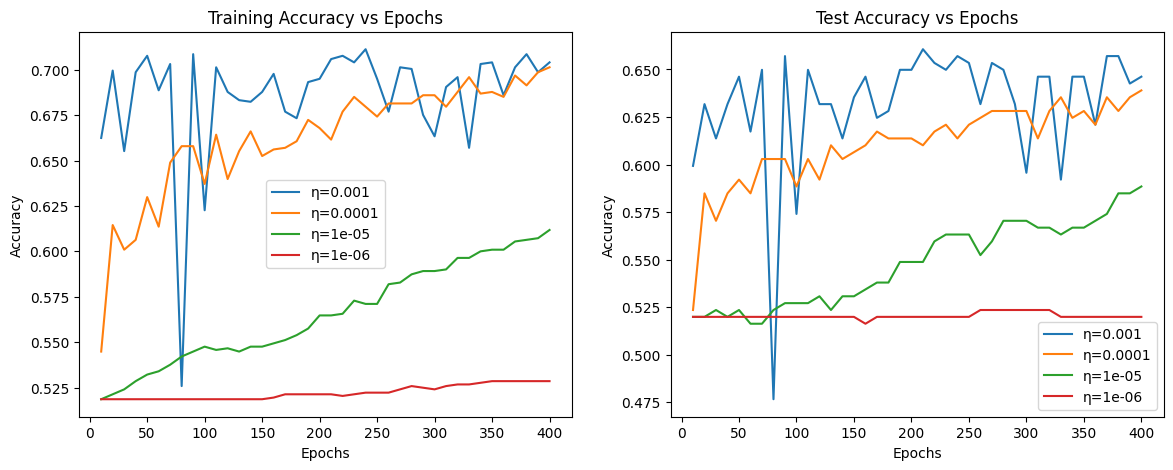

In [147]:
dataset_handler = Dataset('/Users/abhigyan/ML/Assignment2/crime.csv')
train_results = {}
test_results = {}

epochs = 400
store_epoch = 10
for eta in [1e-3, 1e-4, 1e-5, 1e-6]:

    # TODO:
    # Finish the code to loop over different values of learning rates (Use the train() function above)

    # You need to store accuracy arrays obtained in the dictionaries provided
    # above (train_results and test_results)

    # Effectively, you will be creating a mapping between eta -> train/test_accuracy_array
    # Therefore, running train_results[eta] should return the train_accuracy_array for that value
    # of eta and likewise for test_results[eta].

    # YOUR CODE HERE
    train_acc, test_acc, _ = train(epochs, eta, store_epoch)
    train_results[eta] = train_acc
    test_results[eta] = test_acc

#Plotting results

epoch_values = list(range(store_epoch, epochs + 1, store_epoch))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

for eta in [1e-3, 1e-4, 1e-5, 1e-6]:
    ax1.plot(epoch_values, train_results[eta], label=f'η={eta}')
    ax2.plot(epoch_values, test_results[eta], label=f'η={eta}')

ax1.set_title('Training Accuracy vs Epochs')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Accuracy')
ax1.legend()

ax2.set_title('Test Accuracy vs Epochs')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Accuracy')
ax2.legend()


plt.show()


Plot training results below.

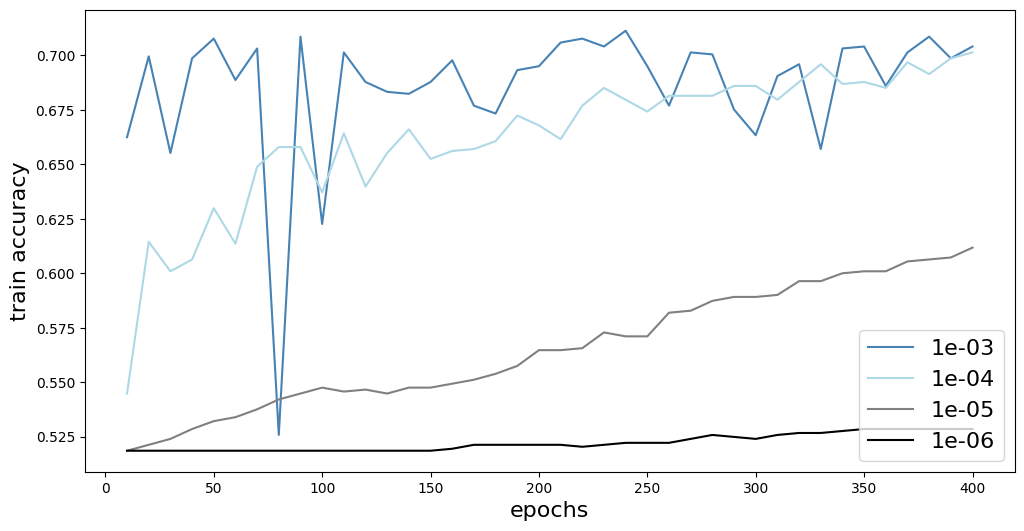

In [148]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(12,6))
epochs_array = [i for i in range(store_epoch, epochs, store_epoch)]
epochs_array.append(epochs)
ax.plot(epochs_array, train_results[1e-3], color="steelblue", label='1e-03')
ax.plot(epochs_array, train_results[1e-4], color="lightblue", label='1e-04')
ax.plot(epochs_array, train_results[1e-5], color="grey", label='1e-05')
ax.plot(epochs_array, train_results[1e-6], color="black", label='1e-06')
ax.legend(loc="lower right", fontsize=16)
ax.set_xlabel("epochs", fontsize=16)
ax.set_ylabel("train accuracy", fontsize=16)
plt.show()

Plot testing results below.

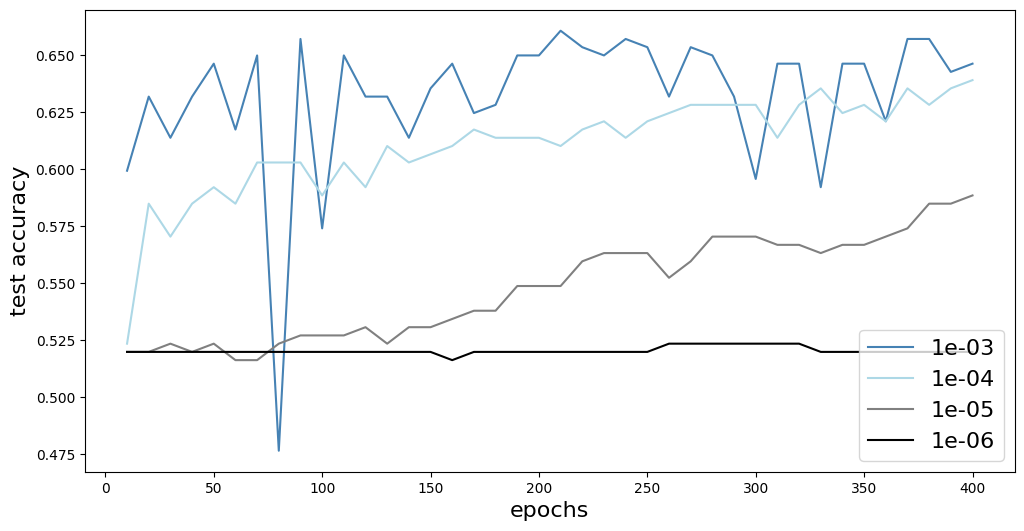

In [149]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(12,6))
epochs_array = [i for i in range(store_epoch,epochs,store_epoch)]
epochs_array.append(epochs)
ax.plot(epochs_array, test_results[1e-3], color="steelblue", label='1e-03')
ax.plot(epochs_array, test_results[1e-4], color="lightblue", label='1e-04')
ax.plot(epochs_array, test_results[1e-5], color="grey", label='1e-05')
ax.plot(epochs_array, test_results[1e-6], color="black", label='1e-06')
ax.legend(loc="lower right", fontsize=16)
ax.set_xlabel("epochs", fontsize=16)
ax.set_ylabel("test accuracy", fontsize=16)
plt.show()

#### Part 2 D [15 points]

Adding $L_2$ regularization to the feature parameters for NLL loss gives:

$$
\textrm{NLL}_{L_2}(\boldsymbol{\mathbf w}) = -\displaystyle\sum_{i=1}^n \left[y_i \log \sigma(\boldsymbol{\mathbf w}^T{\bf x}_i) + (1-y_i)\log(1 - \sigma(\boldsymbol{\mathbf w}^T{\bf x}_i))\right] + \lambda\displaystyle\sum_{k=1}^{p} \mathbf w_{k}^2
$$

where $p$ is the number of features, and $\mathbf w_0$ is the bias term. Notice that $\mathbf w_0$ is not included in the regularization term.

Write down the derivative of the regularized negative log likelihood loss function $\textrm{NLL}_{L_2}$ with respect to $\boldsymbol{\mathbf w}$. Since we are working with SGD, derive it for $n=1$.

YOUR ANSWER HERE:
$$\frac{\partial \text{NLL}_{L_2}}{\partial \mathbf{w}_k} = \begin{cases} (\hat{y} - y)x_k & \text{if } k = 0 \text{ (bias)} \\ (\hat{y} - y)x_k + 2\lambda \mathbf{w}_k & \text{if } k \geq 1 \end{cases}$$

Update your implementation of the `sgd_update` method so that it performs regularized SGD updates of the model parameters to minimize the regularized NLL loss function.

Remember, do **not** regularize the bias parameter $\mathbf w_0$.

Provide train and test accuracy after above change with `lam=1e-5`.

In [150]:
class LogReg:
    def __init__(self, num_features, eta):
        """
        Create a logistic regression classifier
        :param num_features: (int) The number of features (including bias)
        :param eta: (float) learning rate
        """
        self.w = np.zeros(num_features)
        self.eta = eta

    def progress(self, examples_x, examples_y):
        """
        Given a set of examples, compute the probability and accuracy
        :param examples_x: (2D np.ndarray) The features from the dataset to score
        :param examples_y: (1D np.ndarray) The labels from the dataset to score

        :return: (float, float) A tuple of (log probability, accuracy)
        """
        logprob = 0.0
        num_right = 0
        for x_i, y in zip(examples_x, examples_y):
            p = sigmoid(self.w.dot(x_i))
            if y == 1:
                logprob += math.log(p)
            else:
                logprob += math.log(1.0 - p)

            if abs(y - p) <= 0.5:
                num_right += 1

        accuracy = num_right / len(examples_y)
        return logprob, accuracy



    def sgd_update(self, x_i, y, lam=0.0):
       
        y_hat = sigmoid(self.w.dot(x_i))

        gradient = (y_hat - y) * x_i
        gradient[1:] += 2 * lam * self.w[1:]  # L2 regularization, skip bias at index 0

        self.w -= self.eta * gradient
        return self.w

In [151]:
from tests import tests
tests.run_test_suite('prob 2E', LogReg)

testNegRegUpdate (tests.tests.TestLogReg.testNegRegUpdate)
test update based on negative example ... ok
testPosRegUpdate (tests.tests.TestLogReg.testPosRegUpdate)
test regularized update based on positive example ... ok

----------------------------------------------------------------------
Ran 2 tests in 0.001s

OK


In [152]:
eta = 1e-3
epochs = 200
store_epoch = 50

print("With regularization")
train_acc, test_acc, _ = train(epochs, eta, store_epoch, lam=1e-5)
for i in range(len(train_acc)):
    print("\ntrain accuracy after {} epochs: {}".format((i+1)*store_epoch, train_acc[i]))
    print("test accuracy after {} epochs: {}".format((i+1)*store_epoch, test_acc[i]))

print(" Without regularization")
train_acc, test_acc, _ = train(epochs, eta, store_epoch, lam=0)
for i in range(len(train_acc)):
    print("\ntrain accuracy after {} epochs: {}".format((i+1)*store_epoch, train_acc[i]))
    print("test accuracy after {} epochs: {}".format((i+1)*store_epoch, test_acc[i]))

With regularization

train accuracy after 50 epochs: 0.7076923076923077
test accuracy after 50 epochs: 0.6462093862815884

train accuracy after 100 epochs: 0.6226244343891403
test accuracy after 100 epochs: 0.5740072202166066

train accuracy after 150 epochs: 0.6877828054298643
test accuracy after 150 epochs: 0.6353790613718412

train accuracy after 200 epochs: 0.6950226244343891
test accuracy after 200 epochs: 0.6498194945848376
 Without regularization

train accuracy after 50 epochs: 0.7076923076923077
test accuracy after 50 epochs: 0.6462093862815884

train accuracy after 100 epochs: 0.6226244343891403
test accuracy after 100 epochs: 0.5740072202166066

train accuracy after 150 epochs: 0.6877828054298643
test accuracy after 150 epochs: 0.6353790613718412

train accuracy after 200 epochs: 0.6950226244343891
test accuracy after 200 epochs: 0.6498194945848376


In [153]:
eta = 1e-3
epochs = 200
store_epoch = 50

print("With regularization")
train_acc, test_acc, _ = train(epochs, eta, store_epoch, lam=0.1)
for i in range(len(train_acc)):
    print("\ntrain accuracy after {} epochs: {}".format((i+1)*store_epoch, train_acc[i]))
    print("test accuracy after {} epochs: {}".format((i+1)*store_epoch, test_acc[i]))

print(" Without regularization")
train_acc, test_acc, _ = train(epochs, eta, store_epoch, lam=0)
for i in range(len(train_acc)):
    print("\ntrain accuracy after {} epochs: {}".format((i+1)*store_epoch, train_acc[i]))
    print("test accuracy after {} epochs: {}".format((i+1)*store_epoch, test_acc[i]))

With regularization

train accuracy after 50 epochs: 0.6244343891402715
test accuracy after 50 epochs: 0.6389891696750902

train accuracy after 100 epochs: 0.5601809954751131
test accuracy after 100 epochs: 0.5523465703971119

train accuracy after 150 epochs: 0.5990950226244344
test accuracy after 150 epochs: 0.6209386281588448

train accuracy after 200 epochs: 0.6461538461538462
test accuracy after 200 epochs: 0.6678700361010831
 Without regularization

train accuracy after 50 epochs: 0.7076923076923077
test accuracy after 50 epochs: 0.6462093862815884

train accuracy after 100 epochs: 0.6226244343891403
test accuracy after 100 epochs: 0.5740072202166066

train accuracy after 150 epochs: 0.6877828054298643
test accuracy after 150 epochs: 0.6353790613718412

train accuracy after 200 epochs: 0.6950226244343891
test accuracy after 200 epochs: 0.6498194945848376


In the above if we use lam = 1e -5 does not show any difference , but if we use lam = 0.1 there is a differnce due to regularization


#### Part 2 E [8 points]
Update your implementation of train() to incorporate a regularization term. The change should typically be on only one line in your code.

Plot accuracies of different values of $\lambda$ vs. epochs for both training and testing).

In [154]:
dataset_handler = Dataset('/Users/abhigyan/ML/Assignment2/crime.csv')
train_results = {}
test_results = {}
epochs = 400
store_epoch = 10
eta = 1e-4
for lam in [0, 0.1, 0.05, 0.01]:

    # TODO:
    # Finish the code to loop over different values of lambda (Use the train() function above)

    # You need to store accuracy arrays obtained in the dictionaries provided
    # above (train_results and test_results)

    # Effectively, you will be creating a mapping between lambda -> train/test_accuracy_array
    # Therefore, running train_results[lam] should return the train_accuracy_array for that value
    # of lam and likewise for test_results[lam].

    # YOUR CODE HERE
    train_acc, test_acc, _ = train(epochs, eta, store_epoch, lam=lam)
    train_results[lam] = train_acc
    test_results[lam] = test_acc
    

Plot training results below.

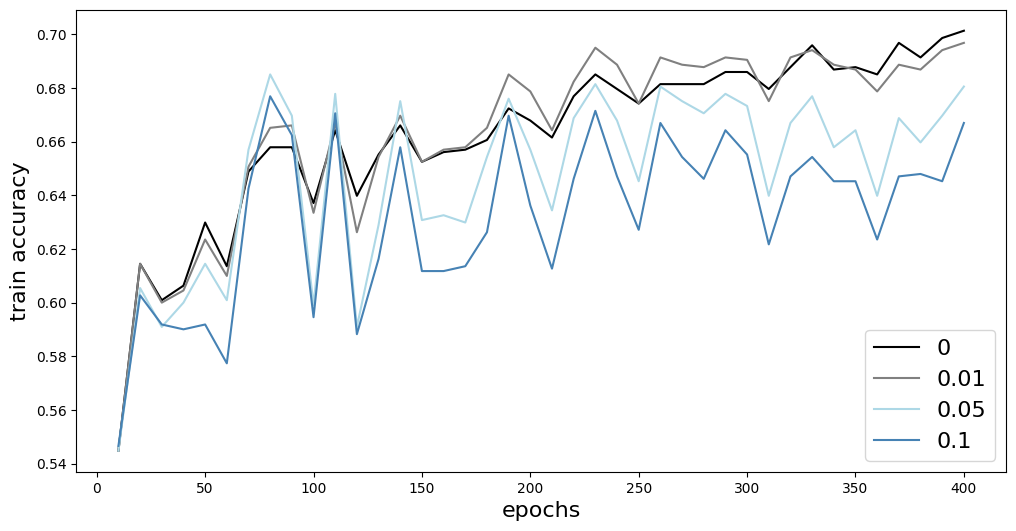

In [155]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(12,6))
epochs_array = [i for i in range(store_epoch,epochs,store_epoch)]
epochs_array.append(epochs)
ax.plot(epochs_array, train_results[0], color="black", label=str(0))
ax.plot(epochs_array, train_results[0.01], color="grey", label=str(0.01))
ax.plot(epochs_array, train_results[0.05], color="lightblue", label=str(0.05))
ax.plot(epochs_array, train_results[0.1], color="steelblue", label=str(0.1))
ax.legend(loc="lower right", fontsize=16)
ax.set_xlabel("epochs", fontsize=16)
ax.set_ylabel("train accuracy", fontsize=16)
plt.show()

Plot testing results below.

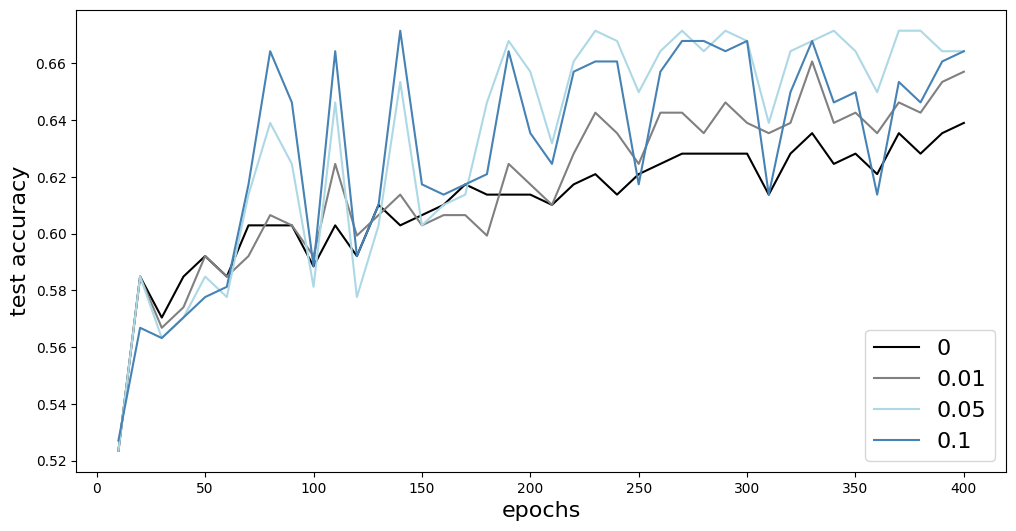

In [156]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(12,6))
epochs_array = [i for i in range(store_epoch,epochs,store_epoch)]
epochs_array.append(epochs)
ax.plot(epochs_array, test_results[0], color="black", label=str(0))
ax.plot(epochs_array, test_results[0.01], color="grey", label=str(0.01))
ax.plot(epochs_array, test_results[0.05], color="lightblue", label=str(0.05))
ax.plot(epochs_array, test_results[0.1], color="steelblue", label=str(0.1))
ax.legend(loc="lower right", fontsize=16)
ax.set_xlabel("epochs", fontsize=16)
ax.set_ylabel("test accuracy", fontsize=16)
plt.show()

### Part 2 F [7 points] 
What is the effect of regularization term with respect to accuracy? 

YOUR ANSWER HERE:
L2 Regularization penalizes large weights by adding $\lambda\sum_{k=1}^{p} w_k^2$ to the loss function , which discourages the model from overfitting to the training data 

High $\lambda$ (e.g. $\lambda = 0.1$):
Training accuracy is lower ,the model is heavily constrained and cannot 
 fit the training data as closely.
Test accuracy may improve initially but can also decrease if $\lambda$ 
    is too large, as the model becomes too simple (underfitting).

Low $\lambda$ (e.g. $\lambda = 0.01$):
Training accuracy is higher , fewer constraints on the weights.
     Test accuracy is closer to the unregularized case, with slight improvement 
    in generalization.

There is a trade-off between bias and variance. Too much regularization 
increases bias (underfitting), while too little risks high variance (overfitting). 
The optimal $\lambda$ balances training and test accuracy, improving generalization 
without sacrificing too much training performance.



### Part 3 [10 points] 

Time based Learning Rate is dynamic learning rate given the following equation:

$\textrm{LearningRate} = \eta\, / \,(1 + \textrm{decay} \cdot \textrm{current epoch})$


#### Part 3 A [8 points] 

Train SGD with the dynamic learning rate defined above and follow these instructions:
* Use initial learning rate $\eta = 0.1$.
* Use $\textrm{decay} = 0.001$.
* Update learning rate `lr.eta` every epoch.
* Use $\lambda = 0$ (no regularization)
* Plot train accuracy and learning rate together for each epoch.

The above can be accomplished by changing one line in `train()` from Part 2a. 

In [157]:
eta  = 1e-1
epochs = 200
store_epoch = 1

# Lists required for plotting
train_accuracy_array = None
learning_rates = None

# YOUR CODE HERE
train_acc, test_acc, learning_rates = train(epochs, eta, store_epoch, decay=1e-3)
train_accuracy_array = train_acc

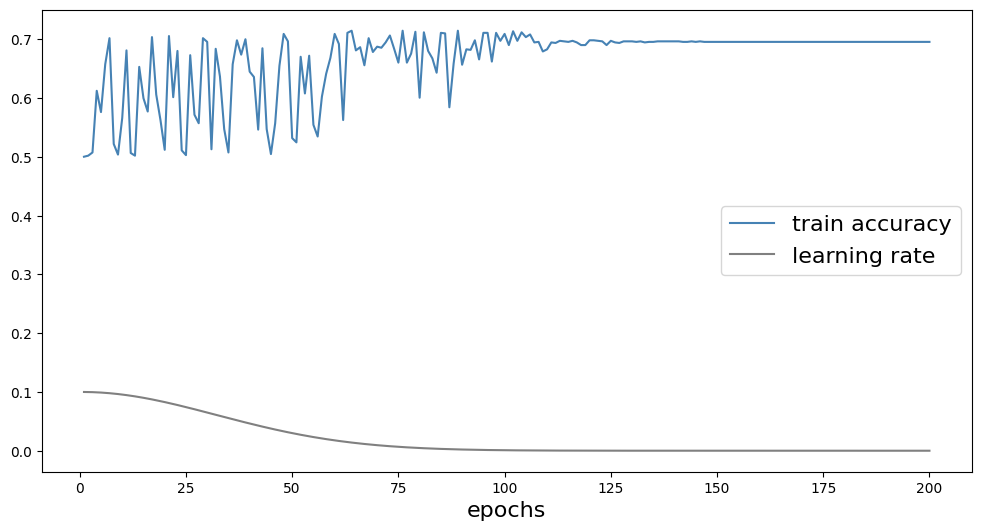

In [158]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(12,6))
epochs_array = [i for i in range(1,epochs)]
epochs_array.append(epochs)
ax.plot(epochs_array, train_accuracy_array, color="steelblue", label=str('train accuracy'))
ax.plot(epochs_array, learning_rates,color="grey", label=str('learning rate'))
ax.legend(loc="center right", fontsize=16)
ax.set_xlabel("epochs", fontsize=16)
ax.set_ylabel("", fontsize=16)
plt.show()

#### Part 3 B [2 points] 

In 2-3 sentences, write your interpretation of the graph you created. 

YOUR ANSWER HERE

With a decay of 0.001 and initial learning rate = 0.1 , the learning rate decreases slightly. Since the decay is very small , the learning rate remains high enough to cause overshooting, resulting in train accuracy that oscillates between 0.7 to 0.5 without converging. A large decay would be needed to observe the effect of time based learning rate decay. 

Acknowledgment: Noah Smith, Chris Ketelsen, Chenhao Tan